# Subscription Analytics & Churn — analyse complète

**Objectif** : à partir de trois tables applicatives brutes, produire un dataset
analytique propre, un modèle de churn à 90 jours sans fuite de données, et une
décision business chiffrée.

Ce notebook déroule tout le raisonnement. Il est une **couche de présentation au-dessus
des modules de production** (`cleaning.py`, `build_dataset.py`, `metrics.py`,
`features.py`, `train.py`, `predict.py`) : chaque résultat ci-dessous est calculé par le
même code que le pipeline scripté (`python run_all.py`, conteneurisé par le `Dockerfile`)
— aucune divergence possible entre ce qui est présenté et ce qui est livré.

**Sommaire**
1. Données brutes : ce qui cloche
2. Partie 1 — Nettoyage
3. Partie 2 — Dataset analytique
4. Partie 3 — Métriques (base active, MRR, cohortes)
5. Partie 4 — Modèle de churn 90 j (cible, anti-fuite, validation temporelle, seuil par le coût)
6. Partie 5 — Note métier
7. Limites & reproductibilité

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Palette (jeu de référence validé : contraste >= 3:1 sur fond clair, dE CVD ok)
BLUE, AQUA, YELLOW, RED = "#2a78d6", "#1baf7a", "#eda100", "#e34948"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
INK, INK2, MUTED, GRID, BASE, SURF = ("#0b0b0b", "#52514e", "#898781",
                                      "#e1e0d9", "#c3c2b7", "#fcfcfb")
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "figure.dpi": 110,
    "axes.edgecolor": BASE, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "text.color": INK,
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.size": 10, "axes.titlesize": 11, "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.titleweight": "bold",
})

RAW = {name: pd.read_csv(f"{name}_raw.csv")
       for name in ("users", "subscriptions", "events")}
{k: v.shape for k, v in RAW.items()}

{'users': (860, 7), 'subscriptions': (840, 11), 'events': (92765, 3)}

## 1 · Données brutes : ce qui cloche

Avant de nettoyer, on identifie précisément les problèmes injectés dans les données.

In [2]:
print("Doublons -> users:", RAW["users"].user_id.duplicated().sum(),
      "| subscriptions:", RAW["subscriptions"].subscription_id.duplicated().sum(),
      "| events (lignes identiques):", RAW["events"].duplicated().sum())

print("\nFormats de dates melanges (users.created_at) :")
print(RAW["users"].created_at.sample(6, random_state=1).tolist())

print("\nVariantes de plan_name :")
print(RAW["subscriptions"].plan_name.value_counts().to_dict())

Doublons -> users: 60 | subscriptions: 40 | events (lignes identiques): 12326

Formats de dates melanges (users.created_at) :
['2024-07-31', '2025/05/24 00:00:00', '2026/03/17 00:00:00', '2024-02-25T00:00:00Z', '03/10/2024', '2025/01/30 00:00:00']

Variantes de plan_name :
{'BASIC': 85, 'BAsic': 83, 'Basic ': 80, 'Basic': 80, 'Bacic': 78, 'basic': 62, 'pro': 49, 'Pro ': 44, 'Pro': 42, 'Proo': 39, 'PRO': 39, 'pr0': 34, 'Premium': 28, 'Premuim': 22, 'Premiun': 21, 'PREMIUM': 19, 'premium': 18, 'Premium ': 17}


## 2 · Partie 1 — Nettoyage

Décisions (implémentées dans `cleaning.py`, détail dans `NOTES_CHOIX.md`) :

- **Doublons** : tous sont des copies strictement identiques → suppression directe.
  La règle prévue pour un éventuel conflit (`cleaning.dedupe`) : garder la ligne la plus
  complète, départagée par la date la plus récente.
- **Dates** : 6 formats explicitement listés, pas de parsing "magique". L'ordre
  jour/mois des motifs ambigus `DD/MM` et `DD-MM` est prouvé par les 65 % de valeurs
  dont le premier composant dépasse 12.
- **`plan_name`** : normalisation casse/espaces + table de typos, puis **contrôle croisé
  avec `monthly_price`** (9,99 ↔ Basic, 19,99 ↔ Pro, 39,99 ↔ Premium) : 100 % cohérent.
- **Events** : granularité journalière → 1 événement par (user, jour, type).

In [3]:
import cleaning

users = cleaning.clean_users()
subs = cleaning.clean_subscriptions()
events = cleaning.clean_events()

users_raw:
  motifs DD/MM ou DD-MM : 286 valeurs, 65% avec jour > 12 (ordre jour/mois confirmé)
  user_id: 860 lignes -> 800 (60 doublons exacts, 0 conflits arbitrés)
subscriptions_raw:
  plan_name standardisé : {'Basic': 468, 'Pro': 247, 'Premium': 125} (100% cohérent avec monthly_price)
  subscription_id: 840 lignes -> 800 (40 doublons exacts, 0 conflits arbitrés)
events_raw:
  92765 lignes -> 80439 (12326 doublons exacts)


## 3 · Partie 2 — Dataset analytique

Une ligne par abonnement, attributs contractuels + profil utilisateur.
`tenure_days` court jusqu'à la résiliation (churns) ou jusqu'à la date d'extraction
(actifs) ; `cohort_month` dérive de la date de début.

In [4]:
import build_dataset

snapshot = events["event_date"].max()  # date d'extraction = dernier evenement observe
analytics = build_dataset.build(subs, users, snapshot)
print(f"snapshot {snapshot.date()} — {len(analytics)} abonnements, "
      f"{analytics.is_active.sum()} actifs / {(1 - analytics.is_active).sum()} resilies")
analytics.head(3)

snapshot 2026-07-05 — 800 abonnements, 702 actifs / 98 resilies


,subscription_id,user_id,plan_name,subscription_start_date,subscription_end_date,is_active,tenure_days,total_revenue,monthly_price,auto_renew,billing_cycle,last_payment_date,country,signup_source,device_type,age,cohort_month
0,s_000001,u_00001,Pro,2025-07-28,NaT,1,342,233.65,19.99,True,monthly,2026-06-26,DE,mobile,mobile,49,2025-07
1,s_000002,u_00002,Premium,2024-01-30,NaT,1,887,1232.60,39.99,True,monthly,2026-06-26,UK,web,desktop,49,2024-01
2,s_000003,u_00003,Premium,2026-01-25,NaT,1,161,217.73,39.99,True,yearly,2026-07-06,ES,referral,mobile,29,2026-01


## 4 · Partie 3 — Métriques

Conventions : un abonnement compte comme actif un mois donné s'il est actif au dernier
jour du mois ; le MRR normalise les cycles annuels en équivalent mensuel ; on s'arrête
au dernier mois complet (juin 2026, le snapshot tombant le 5 juillet).

In [5]:
import metrics

monthly = metrics.monthly_metrics(analytics)
plans = metrics.by_plan(analytics)
channels = metrics.by_channel(analytics)
cohorts = metrics.cohort_table(analytics)
monthly.tail(6)

,month,active_subscribers,new_subscriptions,cancellations,mrr,net_change,cumulative_revenue
24,2026-01,770,48,0,13362.30,48,154472.92
25,2026-02,799,29,0,13842.01,29,168314.93
26,2026-03,800,1,0,13852.00,1,182166.93
27,2026-04,773,0,27,13482.27,-27,195649.20
28,2026-05,741,0,32,12952.59,-32,208601.79
29,2026-06,702,0,39,12352.98,-39,220954.77


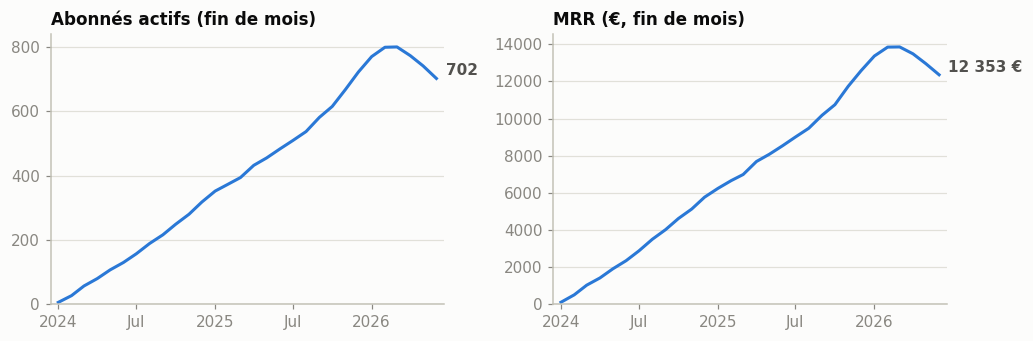

In [6]:
import matplotlib.dates as mdates

m = monthly.assign(d=pd.PeriodIndex(monthly["month"], freq="M").to_timestamp())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.2))
for ax, col, label, fmt in ((ax1, "active_subscribers", "Abonnés actifs (fin de mois)", "{:.0f}"),
                            (ax2, "mrr", "MRR (€, fin de mois)", "{:,.0f} €")):
    ax.plot(m["d"], m[col], color=BLUE, linewidth=2)
    ax.set_title(label)
    ax.grid(axis="x", visible=False)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    last = m.iloc[-1]
    ax.annotate(fmt.format(last[col]).replace(",", " "), (last["d"], last[col]),
                xytext=(6, 2), textcoords="offset points", color=INK2, fontweight="bold")
    ax.margins(x=0.02)
fig.tight_layout()
plt.show()

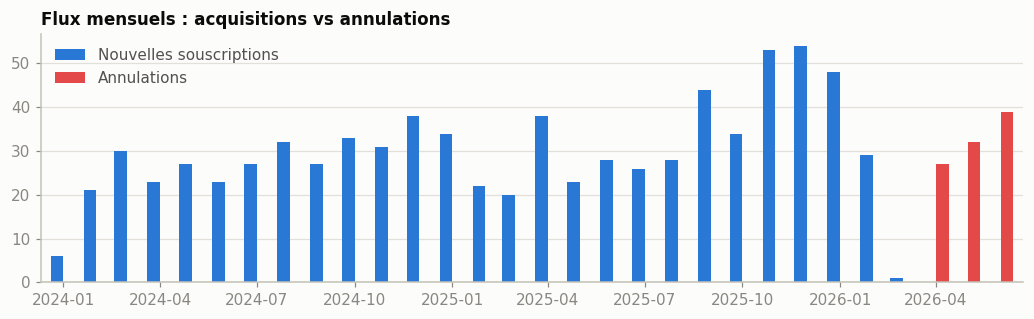

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 3.0))
w = 12  # jours, demi-largeur des barres mensuelles
ax.bar(m["d"] - pd.Timedelta(days=6), m["new_subscriptions"], width=w,
       color=BLUE, label="Nouvelles souscriptions")
ax.bar(m["d"] + pd.Timedelta(days=6), m["cancellations"], width=w,
       color=RED, label="Annulations")
ax.set_title("Flux mensuels : acquisitions vs annulations")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper left", labelcolor=INK2)
ax.margins(x=0.01)
fig.tight_layout()
plt.show()

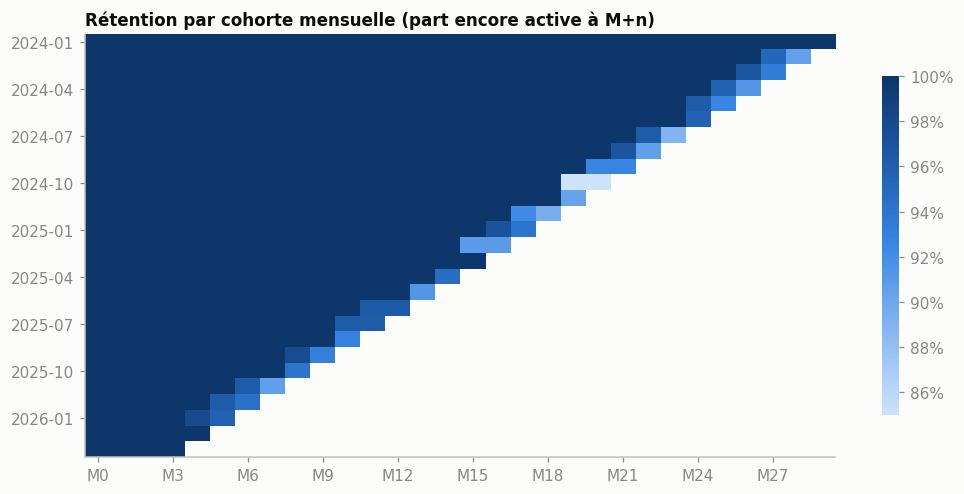

In [8]:
from matplotlib.colors import LinearSegmentedColormap

ret = cohorts.set_index("cohort_month").drop(columns="cohort_size").astype(float)
cmap = LinearSegmentedColormap.from_list("seq_blue", SEQ)
cmap.set_bad(SURF)  # cellules non observables (cohortes trop recentes)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
im = ax.imshow(ret.values, cmap=cmap, vmin=0.85, vmax=1.0, aspect="auto")
ax.set_title("Rétention par cohorte mensuelle (part encore active à M+n)")
ax.set_xticks(range(0, ret.shape[1], 3), [f"M{i}" for i in range(0, ret.shape[1], 3)])
ax.set_yticks(range(0, len(ret), 3), ret.index[::3])
ax.grid(visible=False)
cb = fig.colorbar(im, ax=ax, shrink=0.8, format=lambda x, _: f"{x:.0%}")
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

**Lecture des chiffres clés**

- Base active : **702 abonnés** fin juin 2026, **MRR 12 353 €**. Croissance régulière
  depuis janvier 2024, puis les acquisitions se tarissent début 2026 et **toutes les
  résiliations se concentrent sur avril–juin 2026** : 98 départs, soit 12,2 % de la
  base du trimestre — visible aussi dans la heatmap, où la rétention ne décroche
  qu'aux offsets récents de chaque cohorte.
- **Premium porte 35 % du MRR avec 109 actifs seulement** ; Basic domine en volume
  (386 actifs) mais churne le plus (14 % vs 8 % pour Premium).
- Le churn est homogène entre canaux d'acquisition (12–16 %) : pas de canal toxique,
  la rétention se joue sur l'usage.
- Revenu cumulé reconnu depuis l'origine : **≈ 221 000 €**.

## 5 · Partie 4 — Modèle de churn à 90 jours

### 5.1 · La cible, noir sur blanc

- **Date d'observation** `T = snapshot − 90 j = 2026-04-06` : la dernière date dont la
  fenêtre de résultat `]T, T+90j]` est entièrement observable dans les données.
- **Population** : abonnements **actifs à T** (commencés ≤ T, non résiliés à T) — on ne
  prédit pas le churn de clients déjà partis.
- **`churn_90d = 1`** si, dans `]T, T+90j]` : résiliation (`end_date` dans la fenêtre),
  **ou** arrêt des paiements d'un cycle **mensuel** (zéro paiement alors que ~3 échéances
  tombent dans la fenêtre).

Le piège de la définition "cesse de payer" : **l'absence de paiement d'un cycle annuel
n'est pas un signal** — l'échéance peut légitimement tomber hors fenêtre. Vérifié dans
les données : les 114 abonnés annuels sans paiement dans la fenêtre se connectent
encore tous début juillet. Le code de la cible (`features.build_target`) :

In [9]:
import inspect

import features

print(inspect.getsource(features.build_target))

def build_target(
    subs: pd.DataFrame,
    events: pd.DataFrame,
    T: pd.Timestamp,
    horizon_days: int = 90,
) -> pd.Series:
    """churn_90d pour les actifs à T.

    churn = 1 si, dans la fenêtre ]T, T+90j] :
      - l'abonnement est résilié (end_date dans la fenêtre), OU
      - l'utilisateur en cycle mensuel cesse de payer (aucun événement
        payment dans la fenêtre, alors que ~3 échéances y tombent).
    L'absence de paiement d'un cycle annuel n'est pas un signal : son
    échéance peut légitimement tomber hors fenêtre.
    """
    H = T + pd.Timedelta(days=horizon_days)
    pop = active_at(subs, T).set_index("user_id")

    cancelled = pop["end_date"].notna() & (pop["end_date"] <= H)

    pay_window = events[
        (events["event_type"] == "payment")
        & (events["event_date"] > T)
        & (events["event_date"] <= H)
    ]
    paid = pop.index.isin(pay_window["user_id"])
    stopped_paying = (pop["billing_cycle"] == "monthly") & ~paid & ~cancelled

    targe

In [10]:
HORIZON = 90
T = snapshot - pd.Timedelta(days=HORIZON)
y = features.build_target(subs, events, T, HORIZON)

  cible à T=2026-04-06 : 799 actifs, 97 résiliations + 0 arrêts de paiement silencieux = 12.1% de churn


### 5.2 · Anti-fuite : features connues à T, rien d'autre

Toutes les features sont calculées **exclusivement sur `]-∞, T]`** dans `features.py`
(module partagé entre entraînement et scoring — aucune divergence train/serving) :

| Bloc | Features | Légitimité à T |
|---|---|---|
| Usage | `days_since_last_login`, `logins_30/60/90d`, `usage_trend` (30 j vs 30 j précédents), `logins_per_week_lifetime` | événements filtrés à ≤ T |
| Paiement | `days_since_last_payment`, `payment_overdue_ratio` (récence/cycle), `payment_gap_std` | recalculées depuis `events`, **pas** depuis la colonne snapshot |
| Contrat | `plan_name`, `monthly_price`, `billing_cycle`, `auto_renew`, `tenure_days_at_T` | connus dès la souscription ; ancienneté **à T** |
| Profil | `country`, `signup_source`, `device_type`, `age` | connus à l'inscription |

**Exclues (fuite)** : `status` et `end_date` (encodent la cible), `total_revenue`
(agrégé jusqu'à l'extraction), et — le piège le plus discret — **`last_payment_date`** :
c'est une colonne *au moment de l'extraction* (son max, 2026-07-06, est postérieur à T).
La récence de paiement est donc recalculée depuis les événements filtrés à T.

In [11]:
X = features.build_features(subs, users, events, T)
print(f"{X.shape[0]} actifs a T x {len(features.FEATURES)} features")
print("Exclues (fuite) :", features.LEAKY_COLUMNS + ["is_active", "tenure_days"])
X[features.FEATURES].head(3)

799 actifs a T x 18 features
Exclues (fuite) : ['status', 'end_date', 'total_revenue', 'last_payment_date', 'is_active', 'tenure_days']


,days_since_last_login,logins_30d,logins_60d,logins_90d,usage_trend,logins_per_week_lifetime,days_since_last_payment,payment_overdue_ratio,payment_gap_std,tenure_days_at_T,monthly_price,age,auto_renew,plan_name,billing_cycle,country,signup_source,device_type
user_id,,,,,,,,,,,,,,,,,,
u_00001,2,5.0,9,13,1.200000,0.916667,12.0,0.400000,0.0,252,19.99,49,1,Pro,monthly,DE,mobile,mobile
u_00002,2,7.0,18,27,0.666667,1.879548,17.0,0.566667,6.0,797,39.99,49,1,Premium,monthly,UK,web,desktop
u_00003,5,7.0,18,23,0.666667,2.267606,71.0,0.194521,0.0,71,39.99,29,1,Premium,yearly,ES,referral,mobile


### 5.3 · Validation temporelle, pas aléatoire

Toutes les résiliations tombent dans une seule fenêtre de 90 j en fin d'historique : on
ne peut pas tester sur une date T ultérieure. La dimension temporelle restante est la
**cohorte d'inscription** — entraînement sur les cohortes anciennes, test sur les 25 %
les plus récentes.

Un `train_test_split` aléatoire serait trompeur : il mélangerait les cohortes entre
train et test, laissant le modèle exploiter des régularités propres à chaque période
(mix de plans, intensité d'usage) — alors qu'en production on score toujours des
cohortes **plus récentes** que celles de l'entraînement. La sélection de modèle se fait
sur un second split temporel **interne au train** : le test ne sert qu'une fois.

In [12]:
import train

train_mask, cutoff = train.temporal_split(X, train.TEST_COHORT_SHARE)
X_tr, y_tr, X_te, y_te = X[train_mask], y[train_mask], X[~train_mask], y[~train_mask]
print(f"cutoff {cutoff.date()} — train {len(X_tr)} lignes (churn {y_tr.mean():.1%}), "
      f"test {len(X_te)} lignes (churn {y_te.mean():.1%})")

cutoff 2025-10-20 — train 599 lignes (churn 12.5%), test 200 lignes (churn 11.0%)


### 5.4 · Entraînement et sélection

Deux candidats (régression logistique régularisée, gradient boosting d'histogrammes),
départagés à l'AUC sur la validation temporelle interne, puis champion réentraîné sur
tout le train et évalué une seule fois sur le test. Pas de repondération de classes :
le seuil de décision s'appliquera à des probabilités approximativement calibrées.

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve

inner_mask, inner_cutoff = train.temporal_split(X_tr, train.TEST_COHORT_SHARE)
val_auc = {}
for name, pipe in train.make_candidates().items():
    pipe.fit(X_tr[inner_mask][features.FEATURES], y_tr[inner_mask])
    p_val = pipe.predict_proba(X_tr[~inner_mask][features.FEATURES])[:, 1]
    val_auc[name] = roc_auc_score(y_tr[~inner_mask], p_val)
    print(f"validation interne — {name}: AUC {val_auc[name]:.3f}")

champion = max(val_auc, key=val_auc.get)
model = train.make_candidates()[champion]
model.fit(X_tr[features.FEATURES], y_tr)

proba = model.predict_proba(X_te[features.FEATURES])[:, 1]
auc = roc_auc_score(y_te, proba)
print(f"\nchampion : {champion} — AUC test {auc:.3f}")

validation interne — logistic_regression: AUC 0.702
validation interne — hist_gradient_boosting: AUC 0.800



champion : hist_gradient_boosting — AUC test 0.751


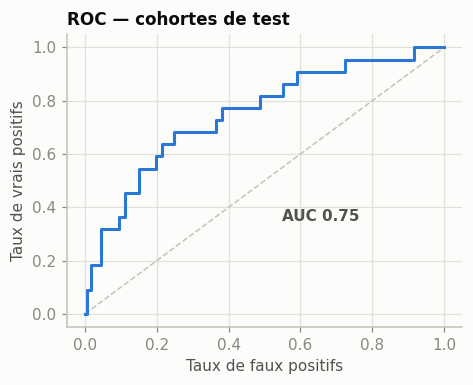

In [14]:
fpr, tpr, _ = roc_curve(y_te, proba)
fig, ax = plt.subplots(figsize=(4.4, 3.6))
ax.plot([0, 1], [0, 1], color=BASE, linewidth=1, linestyle="--")
ax.plot(fpr, tpr, color=BLUE, linewidth=2)
ax.annotate(f"AUC {auc:.2f}", (0.55, 0.35), color=INK2, fontweight="bold")
ax.set_title("ROC — cohortes de test")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
fig.tight_layout()
plt.show()

### 5.5 · Le seuil de décision : par le coût, pas par le F1

Cibler un client coûte *Y* ; s'il allait churner, l'action le retient avec probabilité
*Z* et préserve ~6 mois de revenu *V*. L'espérance de gain d'un ciblage est positive
ssi `p × Z × V > Y`, d'où **p\* = Y / (Z × V)** — aucun F1 là-dedans : rappeler à tort
coûte 2–10 €, rater un churner coûte 60–240 €, et cette asymétrie pousse le seuil bien
sous 0,5. La courbe ci-dessous montre le gain réalisé sur le test selon le seuil, pour
trois actions de rétention.

In [15]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

avg_value = train.SAVED_MONTHS * X["monthly_price"].mean()
p_star = train.RETENTION_COST / (train.CONVERSION * avg_value)
pred = (proba >= p_star).astype(int)

print(f"p* = {train.RETENTION_COST:.0f} / ({train.CONVERSION} x {avg_value:.0f}) = {p_star:.2f}")
print(f"precision {precision_score(y_te, pred):.2f}, rappel {recall_score(y_te, pred):.2f}")
(tn, fp), (fn, tp) = confusion_matrix(y_te, pred)
print(f"matrice de confusion : TN={tn}  FP={fp}  FN={fn}  TP={tp}")

p* = 10 / (0.3 x 104) = 0.32
precision 0.37, rappel 0.32
matrice de confusion : TN=166  FP=12  FN=15  TP=7


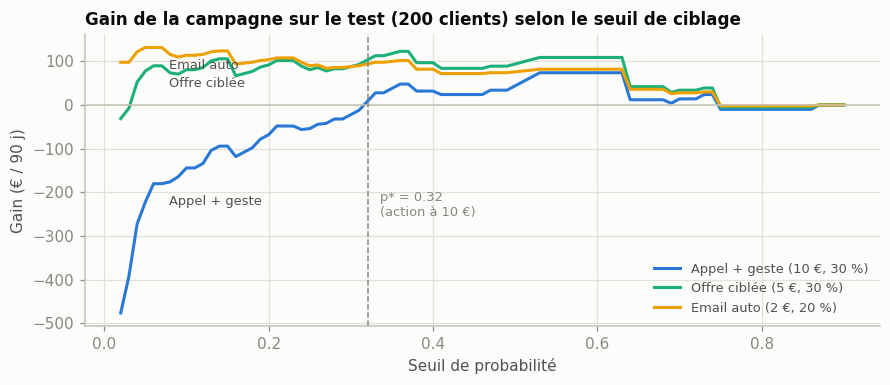

In [16]:
def realized_gain(threshold, cost, conversion):
    sel = proba >= threshold
    saved = (conversion * train.SAVED_MONTHS
             * X_te.loc[sel, "monthly_price"] * y_te[sel]).sum()
    return saved - cost * sel.sum()

scenarios = [("Appel + geste (10 €, 30 %)", 10.0, 0.30, BLUE),
             ("Offre ciblée (5 €, 30 %)", 5.0, 0.30, AQUA),
             ("Email auto (2 €, 20 %)", 2.0, 0.20, YELLOW)]
ts = np.linspace(0.02, 0.9, 89)

fig, ax = plt.subplots(figsize=(8.2, 3.6))
t_anchor = 0.06  # x où les 3 courbes sont bien séparées : labels directs sans collision
for label, cost, conv, color in scenarios:
    gains = [realized_gain(t, cost, conv) for t in ts]
    ax.plot(ts, gains, color=color, linewidth=2, label=label)
    y_anchor = gains[int(np.argmin(np.abs(ts - t_anchor)))]
    ax.annotate(label.split(" (")[0], (t_anchor, y_anchor), xytext=(10, -14),
                textcoords="offset points", color=INK2, fontsize=8.5)
ax.axhline(0, color=BASE, linewidth=1)
ax.axvline(p_star, color=MUTED, linewidth=1, linestyle="--")
ax.annotate(f"p* = {p_star:.2f}\n(action à 10 €)", (p_star, ax.get_ylim()[0] * 0.5),
            xytext=(8, 0), textcoords="offset points", color=MUTED, fontsize=8.5)
ax.set_title("Gain de la campagne sur le test (200 clients) selon le seuil de ciblage")
ax.set_xlabel("Seuil de probabilité")
ax.set_ylabel("Gain (€ / 90 j)")
ax.legend(frameon=False, loc="lower right", labelcolor=INK2, fontsize=8.5)
fig.tight_layout()
plt.show()

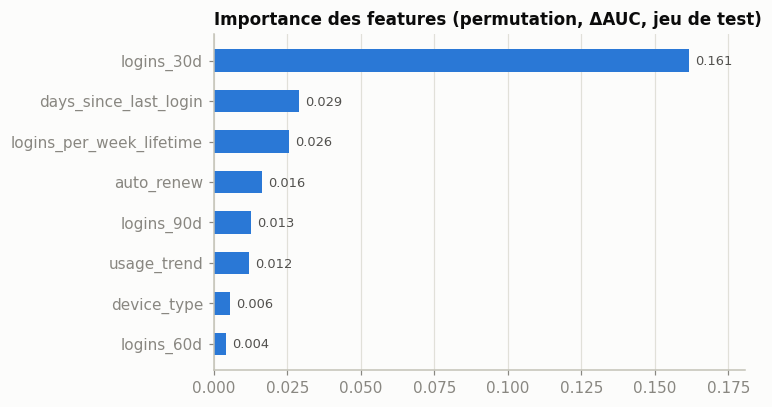

In [17]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(model, X_te[features.FEATURES], y_te,
                             scoring="roc_auc", n_repeats=20, random_state=42)
importance = pd.Series(imp.importances_mean, index=features.FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7.0, 3.8))
top = importance.tail(8)
ax.barh(top.index, top.values, color=BLUE, height=0.55)
for i, v in enumerate(top.values):
    ax.annotate(f"{v:.3f}", (v, i), xytext=(4, -3), textcoords="offset points",
                color=INK2, fontsize=8.5)
ax.set_title("Importance des features (permutation, ΔAUC, jeu de test)")
ax.grid(axis="y", visible=False)
ax.margins(x=0.12)
fig.tight_layout()
plt.show()

**Cohérence métier** : le signal est presque entièrement comportemental — fréquence de
login récente (`logins_30d` domine largement), récence du dernier login, tendance
d'usage. Un client qui churne se désengage avant de résilier. `auto_renew` contribue
(renouvellement manuel = friction). Les features de paiement pèsent peu *dans ces
données* : les mensuels paient jusqu'à la résiliation, la récence de paiement est donc
redondante avec l'activité. Les attributs statiques (pays, device, âge) sont marginaux.

### 5.6 · Scoring de la base active

En production, `predict.py` recalcule les features **à la date de scoring** avec le même
`features.build_features` et sert la probabilité (`python predict.py u_00155`, ou
`--all` pour la base entière). Démonstration au snapshot :

In [18]:
X_now = features.build_features(subs, users, events, snapshot)
scores = pd.DataFrame({
    "user_id": X_now.index,
    "churn_probability": model.predict_proba(X_now[features.FEATURES])[:, 1].round(4),
    "plan": X_now["plan_name"].values,
}).sort_values("churn_probability", ascending=False)
scores["target_for_retention"] = scores["churn_probability"] >= p_star
print(f"{len(scores)} actifs scores, {scores.target_for_retention.sum()} au-dessus du seuil d'action")
scores.head(8)

702 actifs scores, 39 au-dessus du seuil d'action


,user_id,churn_probability,plan,target_for_retention
131,u_00155,0.9750,Basic,True
381,u_00437,0.9381,Pro,True
226,u_00263,0.8669,Basic,True
379,u_00435,0.7989,Pro,True
490,u_00560,0.7720,Basic,True
274,u_00316,0.7659,Pro,True
216,u_00252,0.7606,Pro,True
393,u_00450,0.7165,Premium,True


## 6 · Partie 5 — Note métier : de la prédiction à la décision

**Situation.** Fin juin 2026 : 702 abonnés actifs, MRR 12 353 €. Sur le dernier
trimestre, 98 clients (12,2 % de la base) ont résilié, emportant ~1 500 € de MRR.

**1 · L'enjeu chiffré.** 12,2 % de churn par trimestre ≈ **41 % de la base sur un an** ;
au MRR actuel cela détruit ≈ 5 600 € de MRR en un an, soit **≈ 68 000 € de revenu
annualisé** — sans compter le coût d'acquisition pour reconstituer la base. Nuance :
le churn est concentré sur Basic (churner moyen à 15,3 €/mois vs 17,6 € pour la base) ;
on perd du volume plus que de la valeur, ce qui **borne ce qu'on peut dépenser pour
retenir**.

**2 · Le modèle en action.** Dans les 5 % les plus risqués, 40 % churnent réellement
(3,6× le taux de base). Rentabilité simulée sur le test (200 clients, 22 churners),
en préservant 6 mois de revenu par churner retenu :

| Action | Y | Z | Seuil p* | Ciblés | Churners touchés | Gain / 90 j |
|---|---|---|---|---|---|---|
| Appel + geste commercial | 10 € | 30 % | 0,32 | 19 | 7/22 | **+8 €** |
| Offre ciblée | 5 € | 30 % | 0,16 | 37 | 10/22 | **+67 €** |
| Email/in-app automatisé | 2 € | 20 % | 0,10 | 45 | 12/22 | **+114 €** |

Avec un churner moyen à 15 €/mois, une action coûteuse est à peine rentable ; une action
automatisée bon marché dégage ≈ +114 € par tranche de 200 clients, soit **≈ +400 €/
trimestre (~1 600 €/an) étendue aux 702 actifs**. Le geste coûteux se réserve aux profils
Premium, dont la valeur préservée (240 €) justifie un seuil plus bas.

**3 · Le seuil par le coût, pas par le F1.** `p* = Y / (Z × valeur préservée)` : l'erreur
"contacter à tort" coûte 2–10 €, l'erreur "rater un churner" coûte 60–240 €. Un seuil
optimisé au F1 traiterait ces deux erreurs comme équivalentes — économiquement faux.

**4 · Limites et prochaine donnée utile.** Le modèle ne voit que logins et paiements :
il ne distingue pas churn volontaire et échec de prélèvement, et ne voit ni
l'insatisfaction (tickets, NPS) ni les changements de plan. Priorité de collecte :
**échecs de prélèvement + motif de résiliation** (sépare le churn involontaire,
actionnable par du dunning, du churn d'usage), puis l'usage produit fin pour anticiper
le désengagement plus tôt que la fréquence de login.

## 7 · Limites & reproductibilité

**Limites de validation** : une seule fenêtre de churn observable → validation sur les
cohortes récentes, pas sur une période future ; test de 200 clients (22 churners), donc
métriques encore volatiles. À re-valider dès qu'un second trimestre d'historique existe.

**Reproduire tous les livrables** (mêmes modules que ce notebook) :

```bash
pip install -r requirements.txt && python run_all.py      # local, ~30 s
# ou, sans dépendance locale :
docker build -t churn-pipeline .
docker run --rm -v "$PWD/outputs:/app/outputs" churn-pipeline
```

Livrables : `outputs/analytics_subscriptions.csv`, `outputs/metrics_*.csv`,
`outputs/churn_model.pkl`, `outputs/churn_scores.csv`, `outputs/evaluation.md` ;
documentation : `NOTES_CHOIX.md` (nettoyage + légitimité temporelle des features),
`NOTE_METIER.md` (décision business), `SOLUTION.md` (vue d'ensemble).